# 주문 금액과 고객 만족 — 가설 4

검증할 가설: **주문 금액이 높을수록 고객 만족도가 낮고, 그 차이는 배송으로도 상품 카테고리의 구성으로도 설명되지 않는다.**

앞의 가설들은 배송 약속과 판매자를 개입의 대상으로 보았다.
이 가설이 묻는 것은 주문이 원래 가진 요소, 그중 모든 주문에 값이 있고 계산이 단순한 주문 금액이 만족을 가르는가이다.

가설이 말하는 것은 셋.

1. 주문 금액이 높을수록 리뷰 점수가 낮다
2. 그 차이는 금액이 높은 주문이 약속을 더 자주 어겨서가 아니다
3. 그 차이는 금액이 높은 카테고리의 점수가 원래 낮아서가 아니다

두 번째와 세 번째가 가르는 것은 처방의 대상이다. 배송에서 오는 것이면 06 · 07 의 예상 도착일 처방으로 돌아가고,
카테고리에서 오는 것이면 카테고리가 대상이며, 둘 다 아니면 금액이 높은 주문 자체가 대상이 된다.

주문 금액은 03 에서 정한 대로 상품 금액 + 운임, 주문 단위로 `SUM(price) + SUM(freight_value)`.
결제액은 할부 개월 수에 비례해 불어나는 값이라 쓰지 않는다.

고객 만족도는 05 에서 정한 대로 리뷰 점수(1 ~ 5)로 측정. 공용 표본과 축약 규칙도 05 를 따르며
뷰 `order_review` 를 그대로 사용.

**확인 항목**

- 판정 기준 — 무엇이 나오면 성립하고 무엇이 나오면 불성립인가 (1)
- 표본 — 05 공용 표본에 더 걸 조건과 그때 빠지는 규모, 한 주문의 카테고리 구성 (2)
- 전용 지표 — 주문 금액의 분포와 금액 분위, 상품 금액과 운임의 관계 (3)
- 조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮은가, 높은가 (4)
- 조건 2 — 그 차이가 배송에서 오는가, 운임은 배송에 어떻게 걸리는가 (5)
- 조건 3 — 그 차이가 카테고리 구성에서 오는가 (6)
- 금액대를 맞춘 평가 — 분위별 보정값과 그것이 판매자 판정을 바꾸는지 (7)

## 0. 연결

05 가 만든 뷰 `order_review` 를 사용하므로 05 실행 이후의 상태가 전제.
처음부터 다시 돌릴 때는 02 로 원본을 복원한 뒤 03 · 04 · 05 순서로 실행.

In [1]:
import duckdb

con = duckdb.connect('../olist.duckdb')
con.execute("SET enable_progress_bar = false");

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

BLUE, SAND, RED, GRAY = '#3C6E9F', '#D9A05B', '#B3524B', '#8A8F94'

## 1. 판정 기준

주문 금액은 값 그대로가 아니라 주문 수가 같은 10 개 분위로 나눠 비교한다.
분위마다 주문 수가 같아 한쪽 금액대에 표본이 몰리지 않는다. 금액이 어떻게 흩어져 있는지는 3 에서 확인한다.

양 끝 두 분위만 견주면 가운데 여덟 분위가 빠지므로 **기울기**를 함께 쓴다.
주문 하나를 점으로 놓고, 그 주문이 속한 분위 번호(1 ~ 10)에 리뷰 점수를 회귀한 값이다.
무엇에 대한 기울기인지가 값을 읽는 데 중요하다.

- 가로축은 금액이 아니라 **분위 번호**다. 분위는 주문 수가 같게 나눈 것이므로 한 칸은 금액 순위로 10 % 를 뜻하고,
  한 칸이 담는 금액 폭은 분위마다 다르다. 따라서 기울기는 `금액 1 R$ 당 점수 변화`가 아니라
  `금액 순위에서 10 % 올라갈 때의 점수 변화`다
- 분위를 따라 곧게 움직인다고 보고 직선을 맞춘 값이라, 한쪽 끝에서 급해지는 모양은 이 한 수치에 담기지 않는다.
  그런 모양은 분위별 표와 그림에서 본다
- 같은 방식으로 10 분위를 나눈 것끼리만 견준다. 나누는 범위나 등분 수가 다르면 한 칸의 뜻이 달라진다

**조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮은가, 높은가.**

- 낮아진다 — 최상위 분위의 평균 점수가 최하위 분위보다 낮고 기울기가 음수이며, 둘의 95 % 구간이 0 을 포함하지 않는다.
  1 ~ 2 점 비율은 반대로 오른다
- 높아진다 — 같은 값들의 부호가 반대이고, 구간이 0 을 포함하지 않는다
- 방향 없음 — 차이나 기울기의 구간이 0 을 포함한다

가설이 말하는 것은 낮아진다는 쪽이다.

**조건 2 — 그 차이가 배송에서 오는가.**

금액 분위별 약속 위반율을 보고, 약속을 지킨 주문끼리 분위를 다시 비교한다.
약속을 지킨 주문 안에서도 금액이 높은 분위일수록 소요일이 길 수 있으므로 소요일의 영향을 제외하고 한 번 더 본다.
운임은 배송 거리와 무게를 반영해 매겨지므로 운임으로 나눈 분위도 함께 본다.

- 배송에서 옴 — 약속 준수 여부와 소요일의 영향을 제외하면 방향이 사라진다
- 아님 — 둘의 영향을 제외해도 방향이 남는다

**조건 3 — 그 차이가 카테고리 구성에서 오는가.**

카테고리 구성에서 온다면 카테고리의 가격대와 그 카테고리의 점수 사이에 관계가 있어야 하므로 먼저 그것을 본다.
이어서 카테고리 하나로만 이루어진 주문을 같은 카테고리 안에서 금액 10 분위로 나눠 비교한다.
같은 주문을 조건 1 과 같은 방식으로 다시 10 분위로 나눈 값과 견주면 카테고리 가격대가 설명하는 몫이 나온다.

- 카테고리에서 옴 — 같은 카테고리 안에서 차이가 사라진다
- 아님 — 같은 카테고리 안에서도 방향이 남는다

조건 2 · 3 이 모두 아니면 금액이 높은 주문 자체가 대상이 된다.
배송이 일부만 설명하면 기울기를 약속 위반 구성 · 소요일 구성 · 남는 몫으로 나눠 각각의 크기를 적는다.

## 2. 표본 — 공용 표본에 더 걸 조건

05 의 공용 표본 98,330 건(2017-01 ~ 2018-08 구매 · 리뷰 있음 · 주문 하나에 점수 하나)에 이 가설에만 필요한 조건을 더한다.

- **배송 완료** — 조건 2 가 약속 준수 여부를 쓰므로 배송을 겪고 완료 시각이 남은 주문이어야 함
- **품목 기록 있음** — 주문 금액은 `order_items` 에서 계산하므로 품목이 없는 주문에는 값이 없음

07 과 달리 판매자가 여럿인 주문도 남긴다. 주문 금액은 판매자와 무관하게 주문 단위로 계산된다.

조건을 누적해 걸며 남는 행을 집계. 단계마다 줄어드는 폭이 그 조건에서 빠지는 주문의 규모.

In [3]:
con.execute("""
SELECT '1. 공용 표본' AS step,
       COUNT(*)      AS rows
FROM order_review

UNION ALL
SELECT '2. + 배송 완료', COUNT(*)
FROM order_review
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL

UNION ALL
SELECT '3. + 품목 기록 있음', COUNT(*)
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND EXISTS (SELECT 1 FROM order_items AS i WHERE i.order_id = o.order_id)

ORDER BY step
""").df()

,step,rows
0,1. 공용 표본,98330
1,2. + 배송 완료,95560
2,3. + 품목 기록 있음,95560


공용 표본 98,330 건에서 95,560 건이 남는다. 전체의 97.18 %.

- **배송 미완료 2,770 건** — 배송을 겪지 않아 약속 준수를 물을 수 없는 주문
- **품목 기록 없음 0 건** — 품목이 없는 주문은 배송된 것이 없어 앞 조건에서 이미 전부 빠졌다

한 주문의 카테고리 구성을 확인한다. 카테고리가 여럿이거나 카테고리가 등록되지 않은 상품이 끼면
주문을 카테고리 하나로 묶을 수 없다.

- `category_type` — 등록된 카테고리 하나 / 카테고리 여럿 / 미등록 상품 포함. 미등록 상품이 끼면 카테고리 수와 관계없이 마지막으로 센다
- `orders` · `pct` — 주문 수와 비율

In [4]:
con.execute("""
WITH base AS (
    SELECT order_id
    FROM order_review
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
),
per_order AS (
    SELECT b.order_id,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
    FROM base        AS b
    JOIN order_items AS i ON i.order_id   = b.order_id
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY b.order_id
)
SELECT CASE WHEN unregistered > 0 THEN '3. 미등록 상품 포함'
            WHEN categories > 1   THEN '2. 카테고리 여럿'
            ELSE                       '1. 등록된 카테고리 하나' END AS category_type,
       COUNT(*)                                                 AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)       AS pct
FROM per_order
GROUP BY category_type
ORDER BY category_type
""").df()

,category_type,orders,pct
0,1. 등록된 카테고리 하나,93466,97.81
1,2. 카테고리 여럿,714,0.75
2,3. 미등록 상품 포함,1380,1.44


모든 품목이 등록된 한 카테고리에 속하는 주문은 93,466 건으로 97.81 %.
나머지 2,094 건 중 카테고리가 여럿인 주문이 714 건(0.75 %), 카테고리가 등록되지 않은 상품이 낀 주문이 1,380 건(1.44 %) 이다.

## 3. 전용 지표

2 의 조건을 적용한 결과를 뷰 `amount_review` 로 고정한다. 주문 하나에 한 행이며 05 의 점수와 약속 대비 값을 함께 담는다.

- `items` · `products` — 품목 수와 서로 다른 상품 수
- `price_sum` · `freight_sum` · `order_amount` — 상품 금액, 운임, 주문 금액(둘의 합)
- `category` — 모든 품목이 등록된 한 카테고리에 속하면 그 카테고리의 영문명, 아니면 빈 값. 번역이 없는 카테고리는 원문
- `amount_decile` — 주문 금액 10 분위. 1 이 가장 낮다. 같은 금액이 분위 경계에 걸리면 `order_id` 순으로 나눈다

In [5]:
con.execute("""
CREATE OR REPLACE VIEW amount_review AS
WITH item AS (
    SELECT i.order_id,
           COUNT(*)                                          AS items,
           COUNT(DISTINCT i.product_id)                      AS products,
           SUM(i.price)                                      AS price_sum,
           SUM(i.freight_value)                              AS freight_sum,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered,
           MIN(COALESCE(t.product_category_name_english,
                        p.product_category_name))            AS category_name
    FROM order_items AS i
    JOIN products    AS p ON p.product_id = i.product_id
    LEFT JOIN product_category_name_translation AS t
           ON t.product_category_name = p.product_category_name
    GROUP BY i.order_id
),
base AS (
    SELECT o.order_id,
           o.customer_state,
           o.order_purchase_timestamp,
           o.delivery_days,
           o.days_vs_promise,
           o.review_score,
           it.items,
           it.products,
           it.price_sum,
           it.freight_sum,
           it.price_sum + it.freight_sum AS order_amount,
           CASE WHEN it.categories = 1 AND it.unregistered = 0
                THEN it.category_name END AS category
    FROM order_review AS o
    JOIN item         AS it ON it.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
)
SELECT *,
       NTILE(10) OVER (ORDER BY order_amount, order_id) AS amount_decile
FROM base
""")

con.execute("""
SELECT COUNT(*)                           AS rows,
       COUNT(DISTINCT order_id)           AS orders,
       COUNT(category)                    AS with_category,
       COUNT(*) - COUNT(category)         AS without_category,
       COUNT(*) FILTER (order_amount = 0) AS zero_amount,
       ROUND(MIN(order_amount), 2)        AS min_amount,
       ROUND(MAX(order_amount), 2)        AS max_amount
FROM amount_review
""").df()

,rows,orders,with_category,without_category,zero_amount,min_amount,max_amount
0,95560,95560,93466,2094,0,9.59,13664.08


뷰의 행 수와 주문 수가 95,560 으로 같아 주문 하나에 한 행. 카테고리가 붙은 주문 93,466 건과 빈 값 2,094 건은
위 카테고리 구성의 집계와 같다. 주문 금액이 0 인 주문은 없고 최소 9.59, 최대 13,664.08.

주문 금액의 분포. 평균과 분위수, 주문 금액에서 운임이 차지하는 비율의 중앙값.

In [6]:
con.execute("""
SELECT ROUND(AVG(order_amount), 2)                          AS mean,
       ROUND(quantile_cont(order_amount, 0.10), 2)          AS p10,
       ROUND(quantile_cont(order_amount, 0.25), 2)          AS p25,
       ROUND(quantile_cont(order_amount, 0.50), 2)          AS p50,
       ROUND(quantile_cont(order_amount, 0.75), 2)          AS p75,
       ROUND(quantile_cont(order_amount, 0.90), 2)          AS p90,
       ROUND(quantile_cont(order_amount, 0.99), 2)          AS p99,
       ROUND(MAX(order_amount), 2)                          AS max,
       ROUND(100.0 * MEDIAN(freight_sum / order_amount), 2) AS median_freight_pct
FROM amount_review
""").df()

,mean,p10,p25,p50,p75,p90,p99,max,median_freight_pct
0,159.52,39.48,61.8,105.24,176.15,305.51,1048.6,13664.08,18.33


주문 금액의 중앙값은 105.24, 평균은 159.52 로 평균이 중앙값의 1.5 배다.
상위 10 % 가 305.51, 상위 1 % 가 1,048.60 을 넘고 최대는 13,664.08 로 높은 쪽 꼬리가 길다.
값 그대로 구간을 나누면 높은 금액 구간에 주문이 거의 남지 않으므로 1 에서 정한 대로 주문 수가 같은 분위로 나눈다.

주문 금액에서 운임이 차지하는 비율의 중앙값은 18.33 %.

주문 금액은 상품 금액과 운임의 합이므로 둘이 같이 움직이는지 본다.
금액 분위마다 상품 금액과 운임의 중앙값, 주문 금액에서 운임이 차지하는 비율의 중앙값을 구한다.

- `median_price` · `median_freight` — 상품 금액과 운임의 중앙값
- `median_freight_pct` — 주문 금액에서 운임이 차지하는 비율의 중앙값

In [7]:
con.execute("""
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')         AS decile,
       COUNT(*)                                             AS orders,
       ROUND(MEDIAN(price_sum), 2)                          AS median_price,
       ROUND(MEDIAN(freight_sum), 2)                        AS median_freight,
       ROUND(100.0 * MEDIAN(freight_sum / order_amount), 2) AS median_freight_pct
FROM amount_review
GROUP BY amount_decile
ORDER BY decile
""").df()

,decile,orders,median_price,median_freight,median_freight_pct
0,01,9556,19.90,11.85,38.92
1,02,9556,31.90,15.10,31.65
2,03,9556,47.65,15.10,24.73
3,04,9556,59.90,16.11,21.18
4,05,9556,78.45,16.69,17.87
5,06,9556,99.00,17.88,15.31
6,07,9556,119.90,18.94,13.63
7,08,9556,149.99,21.22,11.96
8,09,9556,204.00,24.19,10.33
9,10,9556,399.00,32.82,6.44


금액이 높은 주문은 운임도 높다. 금액 1 분위에서 상품 금액 중앙값 19.90 · 운임 11.85 이던 것이
10 분위에서 399.00 · 32.82 이 된다. 다만 오르는 폭이 달라 상품 금액이 20 배가 되는 동안 운임은 2.8 배가 된다.

그래서 주문 금액에서 운임이 차지하는 비율은 반대로 내려간다. 1 분위 38.92 % 에서 10 분위 6.44 % 로,
금액이 낮은 주문일수록 운임이 차지하는 몫이 크다.

상품 금액과 운임의 상관계수. 분위 안에서는 주문 금액이 거의 고정되어 상품 금액이 크면 운임이 작아지므로
분위로 나누지 않고 표본 전체에서 구한다. 운임이 0 인 주문 335 건은 로그를 취할 수 없어 뺀다.

- `corr_price_freight` · `corr_log` — 상품 금액과 운임의 상관계수, 둘에 로그를 취한 상관계수
- `corr_amount_freight` — 주문 금액과 운임의 상관계수

In [8]:
con.execute("""
SELECT COUNT(*)                                          AS orders,
       ROUND(CORR(price_sum, freight_sum), 3)            AS corr_price_freight,
       ROUND(CORR(LN(price_sum), LN(freight_sum)), 3)    AS corr_log,
       ROUND(CORR(order_amount, freight_sum), 3)         AS corr_amount_freight
FROM amount_review
WHERE freight_sum > 0
""").df()

,orders,corr_price_freight,corr_log,corr_amount_freight
0,95225,0.41,0.493,0.491


상품 금액과 운임의 상관계수는 0.410, 둘에 로그를 취하면 0.493 이다. 주문 금액과 운임은 0.491.
같은 방향으로 움직이되 한쪽으로 다른 쪽을 가늠할 정도는 아니다.

## 4. 조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮은가, 높은가

금액 10 분위마다 금액의 범위와 점수 분포를 집계한다.

- `min_amount` · `median_amount` · `max_amount` — 분위의 주문 금액
- `multi_item_pct` — 품목이 둘 이상인 주문의 비율
- `avg_score` · `ci_half` — 평균 리뷰 점수와 정규 근사 95 % 구간의 반폭
- `low_pct` · `one_pct` · `five_pct` — 1 ~ 2 점, 1 점, 5 점 비율

In [9]:
dec = con.execute("""
SELECT CASE WHEN GROUPING(amount_decile) = 1 THEN '전체'
            ELSE LPAD(CAST(amount_decile AS VARCHAR), 2, '0') END                 AS decile,
       COUNT(*)                                                                  AS orders,
       ROUND(MIN(order_amount), 2)                                               AS min_amount,
       ROUND(MEDIAN(order_amount), 2)                                            AS median_amount,
       ROUND(MAX(order_amount), 2)                                               AS max_amount,
       ROUND(100.0 * AVG(CASE WHEN items > 1 THEN 1.0 ELSE 0.0 END), 2)          AS multi_item_pct,
       ROUND(AVG(review_score), 3)                                               AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)               AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2)  AS low_pct,
       ROUND(100.0 * AVG(CASE WHEN review_score  = 1 THEN 1.0 ELSE 0.0 END), 2)  AS one_pct,
       ROUND(100.0 * AVG(CASE WHEN review_score  = 5 THEN 1.0 ELSE 0.0 END), 2)  AS five_pct
FROM amount_review
GROUP BY GROUPING SETS ((amount_decile), ())
ORDER BY decile
""").df()
dec

,decile,orders,min_amount,median_amount,max_amount,multi_item_pct,avg_score,ci_half,low_pct,one_pct,five_pct
0,01,9556,9.59,32.38,39.47,0.50,4.246,0.024,10.27,7.46,61.07
1,02,9556,39.48,46.79,54.33,2.57,4.243,0.024,10.27,7.62,61.01
2,03,9556,54.33,61.80,68.40,4.64,4.207,0.025,11.49,8.40,60.61
3,04,9556,68.40,76.16,85.23,6.00,4.194,0.025,11.55,8.85,59.73
4,05,9556,85.23,94.76,105.24,8.30,4.160,0.025,12.58,9.45,58.65
5,06,9556,105.24,116.11,128.25,9.93,4.168,0.025,12.45,9.45,59.34
6,07,9556,128.25,142.19,158.26,12.96,4.152,0.026,12.76,9.73,59.11
7,08,9556,158.27,176.15,201.46,13.17,4.104,0.027,14.33,11.08,58.09
8,09,9556,201.47,236.21,305.51,19.42,4.064,0.027,15.40,11.94,57.50
9,10,9556,305.55,444.79,13664.08,21.91,4.023,0.028,16.87,13.48,57.08


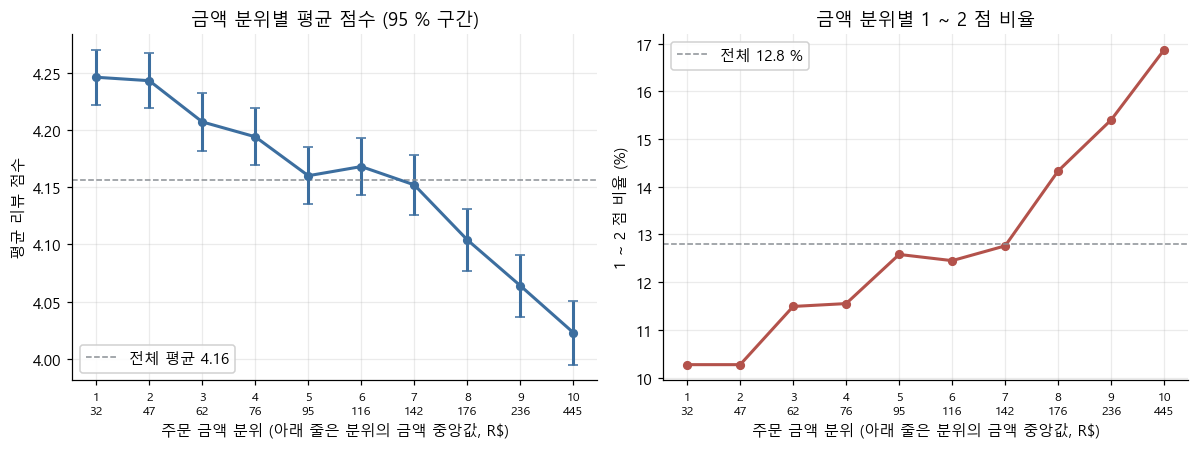

In [10]:
d = dec[dec['decile'] != '전체'].reset_index(drop=True)
overall_avg = dec.loc[dec['decile'] == '전체', 'avg_score'].iloc[0]
overall_low = dec.loc[dec['decile'] == '전체', 'low_pct'].iloc[0]
x = list(range(1, len(d) + 1))
labels = [f'{i}\n{m:,.0f}' for i, m in zip(x, d['median_amount'])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.errorbar(x, d['avg_score'], yerr=d['ci_half'], color=BLUE, marker='o', ms=5, lw=2, capsize=3)
ax.axhline(overall_avg, color=GRAY, lw=1, ls='--', label=f'전체 평균 {overall_avg:.2f}')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('금액 분위별 평균 점수 (95 % 구간)')
ax.legend(loc='lower left', framealpha=0.9)

ax = axes[1]
ax.plot(x, d['low_pct'], color=RED, marker='o', ms=5, lw=2)
ax.axhline(overall_low, color=GRAY, lw=1, ls='--', label=f'전체 {overall_low:.1f} %')
ax.set_ylabel('1 ~ 2 점 비율 (%)')
ax.set_title('금액 분위별 1 ~ 2 점 비율')
ax.legend(loc='upper left', framealpha=0.9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('주문 금액 분위 (아래 줄은 분위의 금액 중앙값, R$)')
plt.tight_layout()
plt.show()

**주문 금액이 높을수록 리뷰 점수가 낮다.** 평균 점수가 1 분위(금액 중앙값 32.38) 4.246 에서 10 분위(444.79) 4.023 으로 내려간다.
1 · 2 분위가 4.246 · 4.243, 5 · 6 분위가 4.160 · 4.168 로 거의 같은 것 외에는 분위가 오를 때마다 낮아진다.

1 ~ 2 점 비율은 10.27 % 에서 16.87 % 로, 1 점 비율은 7.46 % 에서 13.48 % 로 오르고 5 점 비율은 61.07 % 에서 57.08 % 로 내려간다.
오르는 폭은 8 분위부터 커진다. 1 ~ 7 분위의 1 ~ 2 점 비율이 10.27 ~ 12.76 % 인데 8 · 9 · 10 분위는 14.33 · 15.40 · 16.87 % 다.

10 분위는 305.55 에서 13,664.08 까지 범위가 넓다. 품목이 둘 이상인 주문의 비율도 1 분위 0.50 % 에서 10 분위 21.91 % 로 올라,
금액이 높은 분위일수록 여러 품목을 산 주문이 섞인다.
품목의 영향이 있다면, 여러 품목 가운데 점수가 낮은 품목이 포함되었는지가 원인일 수 있다. 이 노트북에서는 확인하지 않는다.

최상위 분위와 최하위 분위의 차이, 그리고 10 개 분위를 모두 쓴 추세를 함께 본다.
끝의 두 분위만으로는 가운데 8 개가 어떻게 움직이는지 들어가지 않는다.

- `diff_avg` · `diff_ci_low` · `diff_ci_high` — 평균 점수의 차이(10 분위 − 1 분위)와 구간
- `diff_low_pp` · `diff_low_ci_half` — 1 ~ 2 점 비율의 차이(%p)와 구간의 반폭
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 구간.
  주문 단위로 분위 번호에 점수를 회귀한 기울기

In [11]:
con.execute("""
WITH s AS (
    SELECT amount_decile AS d,
           review_score
    FROM amount_review
),
g AS (
    SELECT d                                                      AS d,
           COUNT(*)                                               AS n,
           AVG(review_score)                                      AS m,
           VAR_SAMP(review_score)                                 AS v,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low
    FROM s
    WHERE d IN (1, 10)
    GROUP BY d
),
fit AS (
    SELECT regr_slope(review_score, d)                                   AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d))                             AS se
    FROM s
)
SELECT ROUND(hi.m - lo.m, 3)                                                             AS diff_avg,
       ROUND(hi.m - lo.m - 1.96 * SQRT(hi.v / hi.n + lo.v / lo.n), 3)                    AS diff_ci_low,
       ROUND(hi.m - lo.m + 1.96 * SQRT(hi.v / hi.n + lo.v / lo.n), 3)                    AS diff_ci_high,
       ROUND(100 * (hi.low - lo.low), 2)                                                 AS diff_low_pp,
       ROUND(196 * SQRT(hi.low * (1 - hi.low) / hi.n + lo.low * (1 - lo.low) / lo.n), 2) AS diff_low_ci_half,
       ROUND(fit.sl, 4)                                                                  AS slope,
       ROUND(fit.sl - 1.96 * fit.se, 4)                                                  AS slope_ci_low,
       ROUND(fit.sl + 1.96 * fit.se, 4)                                                  AS slope_ci_high
FROM g AS hi
CROSS JOIN g AS lo
CROSS JOIN fit
WHERE hi.d = 10
  AND lo.d = 1
""").df()

,diff_avg,diff_ci_low,diff_ci_high,diff_low_pp,diff_low_ci_half,slope,slope_ci_low,slope_ci_high
0,-0.223,-0.26,-0.186,6.6,0.97,-0.0236,-0.0264,-0.0208


10 분위와 1 분위의 평균 점수 차이는 −0.223 이고 95 % 구간은 −0.260 ~ −0.186 으로 0 을 포함하지 않는다.
1 ~ 2 점 비율의 차이는 6.60 %p, 구간의 반폭은 0.97 %p.

10 개 분위를 모두 쓴 기울기는 분위당 −0.0236(−0.0264 ~ −0.0208) 이다. 아홉 칸을 오르면 −0.212 로,
양 끝만 견준 −0.223 과 크기가 비슷하다. 가운데 분위들도 같은 방향으로 늘어서 있다는 뜻이다.

## 5. 조건 2 — 그 차이가 배송에서 오는가

금액 분위마다 약속 위반율과 소요일, 약속 준수 여부로 나눈 평균 점수를 집계한다.
약속 위반은 `days_vs_promise > 0` 인 주문.

- `late_pct` — 약속 위반율
- `median_days` — 배송 소요일의 중앙값
- `median_days_kept` — 약속을 지킨 주문의 배송 소요일 중앙값
- `kept_orders` · `avg_kept` · `ci_kept` — 약속을 지킨 주문의 수, 평균 점수, 95 % 구간의 반폭
- `avg_late` — 약속을 어긴 주문의 평균 점수

In [12]:
dly = con.execute("""
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')                                AS decile,
       COUNT(*)                                                                   AS orders,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       MEDIAN(delivery_days)                                                      AS median_days,
       MEDIAN(delivery_days) FILTER (days_vs_promise <= 0)                        AS median_days_kept,
       COUNT(*) FILTER (days_vs_promise <= 0)                                     AS kept_orders,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)                  AS avg_kept,
       ROUND(1.96 * STDDEV_SAMP(review_score) FILTER (days_vs_promise <= 0)
             / SQRT(COUNT(*) FILTER (days_vs_promise <= 0)), 3)                   AS ci_kept,
       ROUND(AVG(review_score) FILTER (days_vs_promise > 0), 3)                   AS avg_late
FROM amount_review
GROUP BY amount_decile
ORDER BY decile
""").df()
dly

,decile,orders,late_pct,median_days,median_days_kept,kept_orders,avg_kept,ci_kept,avg_late
0,01,9556,5.36,8.0,8.0,9044,4.347,0.022,2.463
1,02,9556,5.85,9.0,9.0,8997,4.362,0.022,2.320
2,03,9556,6.05,10.0,9.0,8978,4.329,0.023,2.310
3,04,9556,6.60,10.0,10.0,8925,4.332,0.023,2.250
4,05,9556,6.84,10.0,10.0,8902,4.295,0.024,2.321
5,06,9556,6.75,10.0,10.0,8911,4.302,0.024,2.324
6,07,9556,6.99,11.0,10.0,8888,4.294,0.024,2.272
7,08,9556,7.36,11.0,10.0,8853,4.257,0.025,2.179
8,09,9556,7.03,11.0,11.0,8884,4.210,0.026,2.128
9,10,9556,7.91,11.0,11.0,8800,4.178,0.027,2.214


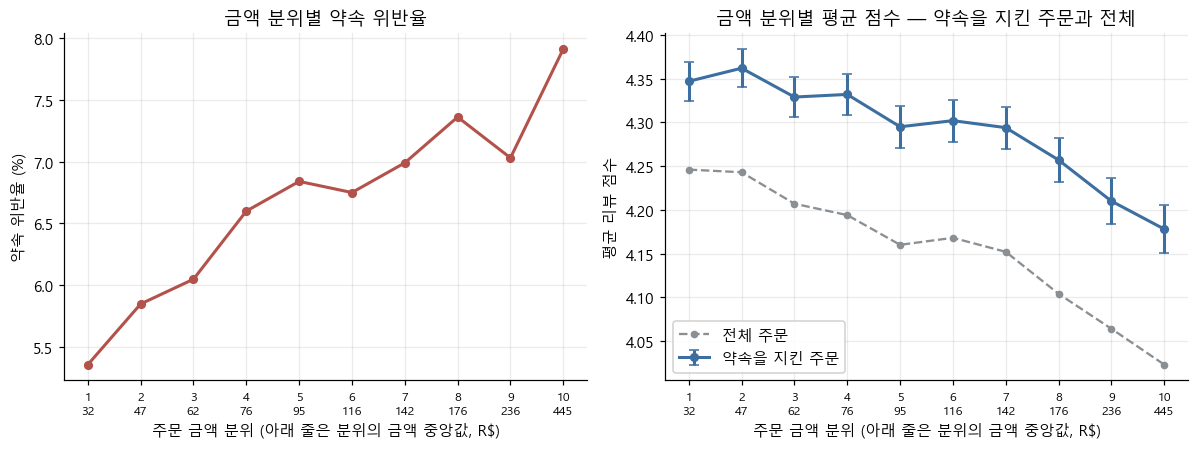

In [13]:
x = list(range(1, len(dly) + 1))
d_all = dec[dec['decile'] != '전체'].reset_index(drop=True)
labels = [f'{i}\n{m:,.0f}' for i, m in zip(x, d_all['median_amount'])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(x, dly['late_pct'], color=RED, marker='o', ms=5, lw=2)
ax.set_ylabel('약속 위반율 (%)')
ax.set_title('금액 분위별 약속 위반율')

ax = axes[1]
ax.errorbar(x, dly['avg_kept'], yerr=dly['ci_kept'], color=BLUE, marker='o', ms=5, lw=2, capsize=3,
            label='약속을 지킨 주문')
ax.plot(x, d_all['avg_score'], color=GRAY, marker='o', ms=4, lw=1.5, ls='--', label='전체 주문')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('금액 분위별 평균 점수 — 약속을 지킨 주문과 전체')
ax.legend(loc='lower left', framealpha=0.9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('주문 금액 분위 (아래 줄은 분위의 금액 중앙값, R$)')
plt.tight_layout()
plt.show()

금액이 높은 분위일수록 약속 위반율이 높다. 1 분위 5.36 % 에서 10 분위 7.91 % 로 오르고,
배송 소요일의 중앙값도 8 일에서 11 일로 길어지며, 약속을 지킨 주문만 따져도 8 일에서 11 일이다.

**약속을 지킨 주문끼리도 금액이 높을수록 점수가 낮다.** 약속을 지킨 주문의 평균이 1 분위 4.347 에서 10 분위 4.178 로 내려간다.
약속을 어긴 주문은 분위마다 2.128 ~ 2.463 으로 약속을 지킨 주문보다 2 점 가까이 낮다.

최상위 분위와 최하위 분위의 평균 격차를 약속 위반에서 온 몫과 나머지로 나누고,
약속을 지킨 주문끼리의 차이도 구간과 함께 낸다.

- `late_share_part` — 위반 비중이 달라서 생긴 몫. 위반율 차이 × 최하위 분위에서 위반 주문과 준수 주문의 점수 차이
- `within_part` — 약속 준수 여부가 같은 주문끼리의 점수 차이에서 온 몫. 두 몫의 합은 격차 `gap` 과 같다
- `late_share_pct` — 위반 비중의 몫이 격차에서 차지하는 비율
- `kept_diff` · `kept_ci_low` · `kept_ci_high` — 약속을 지킨 주문의 10 분위와 1 분위 평균 점수 차이와 95 % 구간

In [14]:
con.execute("""
WITH g AS (
    SELECT amount_decile                                            AS d,
           AVG(review_score)                                        AS m,
           AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS p,
           AVG(review_score)      FILTER (days_vs_promise <= 0)     AS k,
           VAR_SAMP(review_score) FILTER (days_vs_promise <= 0)     AS kv,
           COUNT(*)               FILTER (days_vs_promise <= 0)     AS kn,
           AVG(review_score)      FILTER (days_vs_promise > 0)      AS l
    FROM amount_review
    WHERE amount_decile IN (1, 10)
    GROUP BY amount_decile
)
SELECT ROUND(t.m - b.m, 3)                                            AS gap,
       ROUND((t.p - b.p) * (b.l - b.k), 3)                            AS late_share_part,
       ROUND((1 - t.p) * (t.k - b.k) + t.p * (t.l - b.l), 3)          AS within_part,
       ROUND(100 * (t.p - b.p) * (b.l - b.k) / (t.m - b.m), 1)        AS late_share_pct,
       ROUND(t.k - b.k, 3)                                            AS kept_diff,
       ROUND(t.k - b.k - 1.96 * SQRT(t.kv / t.kn + b.kv / b.kn), 3)   AS kept_ci_low,
       ROUND(t.k - b.k + 1.96 * SQRT(t.kv / t.kn + b.kv / b.kn), 3)   AS kept_ci_high
FROM g AS t
CROSS JOIN g AS b
WHERE t.d = 10
  AND b.d = 1
""").df()

,gap,late_share_part,within_part,late_share_pct,kept_diff,kept_ci_low,kept_ci_high
0,-0.223,-0.048,-0.175,21.5,-0.169,-0.204,-0.134


**격차의 대부분은 약속 위반에서 오지 않는다.** 1 분위와 10 분위의 격차 −0.223 중 위반 비중이 달라서 생긴 몫이
−0.048(21.5 %), 약속 준수 여부가 같은 주문끼리의 차이에서 온 몫이 −0.175(78.5 %) 다.

약속을 지킨 주문끼리의 차이는 −0.169 이고 95 % 구간이 −0.204 ~ −0.134 로 0 을 포함하지 않는다.

약속 준수 여부로 나눠 같은 기울기를 구한다. 위반이 섞이지 않은 주문 안에서도 분위를 따라 내려가는지 본다.

- `orders` — 주문 수
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간

In [15]:
con.execute("""
WITH s AS (
    SELECT '1. 전체 주문'      AS grp, amount_decile AS d, review_score FROM amount_review
    UNION ALL
    SELECT '2. 약속을 지킨 주문', amount_decile,         review_score FROM amount_review
    WHERE days_vs_promise <= 0
    UNION ALL
    SELECT '3. 약속을 어긴 주문', amount_decile,         review_score FROM amount_review
    WHERE days_vs_promise > 0
),
f AS (
    SELECT grp,
           COUNT(*)                           AS orders,
           regr_slope(review_score, d)        AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d)) AS se
    FROM s
    GROUP BY grp
)
SELECT grp,
       orders,
       ROUND(sl, 4)              AS slope,
       ROUND(sl - 1.96 * se, 4)  AS slope_ci_low,
       ROUND(sl + 1.96 * se, 4)  AS slope_ci_high
FROM f
ORDER BY grp
""").df()

,grp,orders,slope,slope_ci_low,slope_ci_high
0,1. 전체 주문,95560,-0.0236,-0.0264,-0.0208
1,2. 약속을 지킨 주문,89182,-0.0185,-0.0211,-0.0158
2,3. 약속을 어긴 주문,6378,-0.0245,-0.0381,-0.0110


약속을 지킨 주문 안에서도 기울기가 남는다. 전체 −0.0236(−0.0264 ~ −0.0208) 에 견주어 약속을 지킨 주문은
−0.0185(−0.0211 ~ −0.0158) 로 78 % 크기이며 구간이 0 을 포함하지 않는다.
약속을 어긴 주문도 −0.0245(−0.0381 ~ −0.0110) 로 방향이 같다.

약속을 지킨 주문 안에서도 금액이 높은 분위일수록 소요일이 길다. 소요일의 영향을 제외하기 위해 소요일 구간을 나누고 그 안에서 같은 기울기를 구한다.
구간은 06 에서 쓴 것과 같다.

- `band` — 배송 소요일 구간
- `orders` · `avg_score` — 약속을 지킨 주문의 수와 평균 점수
- `min_decile_n` — 그 구간에서 주문이 가장 적은 금액 분위의 주문 수
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간

In [16]:
con.execute("""
WITH s AS (
    SELECT CASE WHEN delivery_days <= 7  THEN '1. 0 ~ 7 일'
                WHEN delivery_days <= 14 THEN '2. 8 ~ 14 일'
                WHEN delivery_days <= 21 THEN '3. 15 ~ 21 일'
                WHEN delivery_days <= 30 THEN '4. 22 ~ 30 일'
                ELSE                          '5. 31 일 이상' END AS band,
           amount_decile                                          AS d,
           review_score
    FROM amount_review
    WHERE days_vs_promise <= 0
),
f AS (
    SELECT band,
           COUNT(*)                           AS orders,
           AVG(review_score)                  AS avg_score,
           regr_slope(review_score, d)        AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d)) AS se
    FROM s
    GROUP BY band
),
per_d AS (
    SELECT band, MIN(n) AS min_decile_n
    FROM (SELECT band, d, COUNT(*) AS n FROM s GROUP BY band, d)
    GROUP BY band
)
SELECT f.band,
       f.orders,
       ROUND(f.avg_score, 3)       AS avg_score,
       per_d.min_decile_n,
       ROUND(f.sl, 4)              AS slope,
       ROUND(f.sl - 1.96 * f.se, 4) AS slope_ci_low,
       ROUND(f.sl + 1.96 * f.se, 4) AS slope_ci_high
FROM f
JOIN per_d USING (band)
ORDER BY f.band
""").df()

,band,orders,avg_score,min_decile_n,slope,slope_ci_low,slope_ci_high
0,1. 0 ~ 7 일,30442,4.413,2428,-0.0116,-0.0158,-0.0075
1,2. 8 ~ 14 일,37361,4.308,3247,-0.0120,-0.0160,-0.0079
2,3. 15 ~ 21 일,15414,4.161,1030,-0.0142,-0.0211,-0.0074
3,4. 22 ~ 30 일,5171,3.940,261,-0.0211,-0.0338,-0.0084
4,5. 31 일 이상,794,3.628,24,-0.0247,-0.0620,0.0127


**소요일의 영향을 제외해도 기울기가 남는다.** 0 ~ 7 일 −0.0116, 8 ~ 14 일 −0.0120, 15 ~ 21 일 −0.0142, 22 ~ 30 일 −0.0211 로
네 구간 모두 95 % 구간이 0 을 포함하지 않는다. 31 일 이상은 −0.0247 이나 구간이 −0.0620 ~ 0.0127 로 0 을 포함하며,
그 구간의 약속을 지킨 주문이 794 건, 가장 적은 금액 분위가 24 건이다.

구간 안의 기울기는 약속을 지킨 주문 전체의 −0.0185 보다 작다. 소요일이 긴 구간일수록 기울기가 커진다.

전체 기울기를 배송이 설명하는 몫과 남는 몫으로 나눈다. 약속 준수 여부와 소요일의 영향을 차례로 제외하며
기울기가 줄어드는 폭이 각각의 몫이다.

- `1. 약속 위반 구성` — 전체 기울기와 약속을 지킨 주문의 기울기의 차
- `2. 소요일 구성` — 약속을 지킨 주문의 기울기와 소요일 구간 안 기울기(구간별 기울기를 구간 안 분위의 흩어진 정도 `regr_sxx` 로 가중 평균한 값. 구간마다 평균을 따로 두고 기울기 하나를 맞춘 회귀의 기울기와 같다)의 차
- `3. 남는 몫` — 소요일의 영향까지 제외하고도 남는 기울기
- `pct` — 전체 기울기에서 차지하는 비율

약속을 어긴 주문은 그 안의 기울기가 더 가파르므로, 약속 위반 구성의 몫에는 위반 비중의 차이 외에 그 몫이 조금 섞여 있다.

In [17]:
con.execute("""
WITH kept AS (
    SELECT amount_decile AS d,
           delivery_days,
           review_score
    FROM amount_review
    WHERE days_vs_promise <= 0
),
whole AS (
    SELECT regr_slope(review_score, amount_decile) AS sl
    FROM amount_review
),
kept_fit AS (
    SELECT regr_slope(review_score, d) AS sl
    FROM kept
),
band_fit AS (
    SELECT CASE WHEN delivery_days <= 7  THEN 1
                WHEN delivery_days <= 14 THEN 2
                WHEN delivery_days <= 21 THEN 3
                WHEN delivery_days <= 30 THEN 4
                ELSE                          5 END AS band,
           regr_sxx(review_score, d)               AS sxx,
           regr_slope(review_score, d)             AS sl
    FROM kept
    GROUP BY band
),
within AS (
    SELECT SUM(sxx * sl) / SUM(sxx) AS sl
    FROM band_fit
)
SELECT '1. 약속 위반 구성'                          AS part,
       ROUND(w.sl - k.sl, 4)                      AS slope_part,
       ROUND(100 * (w.sl - k.sl) / w.sl, 1)       AS pct
FROM whole AS w
CROSS JOIN kept_fit AS k

UNION ALL
SELECT '2. 소요일 구성',
       ROUND(k.sl - i.sl, 4),
       ROUND(100 * (k.sl - i.sl) / w.sl, 1)
FROM whole AS w
CROSS JOIN kept_fit AS k
CROSS JOIN within AS i

UNION ALL
SELECT '3. 남는 몫',
       ROUND(i.sl, 4),
       ROUND(100 * i.sl / w.sl, 1)
FROM whole AS w
CROSS JOIN within AS i

UNION ALL
SELECT '4. 전체 기울기',
       ROUND(w.sl, 4),
       100.0
FROM whole AS w

ORDER BY part
""").df()

,part,slope_part,pct
0,1. 약속 위반 구성,-0.0051,21.8
1,2. 소요일 구성,-0.0056,23.8
2,3. 남는 몫,-0.0128,54.4
3,4. 전체 기울기,-0.0236,100.0


**배송으로 설명되는 몫은 기울기의 절반에 조금 못 미친다.** −0.0236 중 약속 위반 구성이 −0.0051(21.8 %),
소요일 구성이 −0.0056(23.8 %) 으로 둘을 합쳐 45.6 % 이고, 배송으로 설명되지 않는 몫이 −0.0128(54.4 %) 다.

약속 위반만 따지면 21.8 % 가 설명되고, 소요일까지 더하면 45.6 % 가 된다.
앞의 1 분위와 10 분위 분해에서 약속 위반이 설명한 21.5 % 는 이 21.8 % 와 같은 자리의 수치다.

운임은 배송 거리와 무게를 반영해 매겨지므로 운임이 높은 주문은 배송도 다를 수 있다.
운임으로 10 분위를 나눠 소요일과 약속 위반율을 본다.

- `median_freight` · `median_amount` — 운임 분위의 운임과 주문 금액의 중앙값
- `median_days` · `late_pct` — 배송 소요일의 중앙값과 약속 위반율
- `avg_score` — 평균 리뷰 점수

In [18]:
con.execute("""
WITH f AS (
    SELECT freight_sum,
           order_amount,
           delivery_days,
           days_vs_promise,
           review_score,
           NTILE(10) OVER (ORDER BY freight_sum, order_id) AS fd
    FROM amount_review
)
SELECT LPAD(CAST(fd AS VARCHAR), 2, '0')                                           AS freight_decile,
       COUNT(*)                                                                   AS orders,
       ROUND(MEDIAN(freight_sum), 2)                                              AS median_freight,
       ROUND(MEDIAN(order_amount), 2)                                             AS median_amount,
       MEDIAN(delivery_days)                                                      AS median_days,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       ROUND(AVG(review_score), 3)                                                AS avg_score
FROM f
GROUP BY fd
ORDER BY freight_decile
""").df()

,freight_decile,orders,median_freight,median_amount,median_days,late_pct,avg_score
0,01,9556,7.87,48.78,5.0,4.21,4.344
1,02,9556,11.85,69.73,7.0,4.61,4.283
2,03,9556,13.83,80.65,9.0,5.14,4.264
3,04,9556,15.11,68.12,11.0,6.73,4.192
4,05,9556,16.34,102.03,12.0,7.45,4.181
5,06,9556,17.99,91.16,12.0,7.52,4.175
6,07,9556,19.75,135.00,12.0,7.64,4.186
7,08,9556,23.99,133.21,12.0,7.45,4.137
8,09,9556,33.08,161.08,13.0,7.65,3.924
9,10,9556,54.70,261.93,13.0,8.34,3.874


**운임이 높은 주문은 배송이 오래 걸리고 약속도 더 자주 어긴다.** 운임 1 분위(중앙값 7.87) 의 소요일 중앙값 5 일 ·
위반율 4.21 % 가 10 분위(54.70) 에서 13 일 · 8.34 % 가 된다. 평균 점수는 4.344 에서 3.874 로 −0.470 내려간다.

이 격차는 금액 분위의 −0.223 보다 크다. 다만 운임 분위를 따라 주문 금액 중앙값도 48.78 에서 261.93 으로 오르므로
두 축이 겹쳐 있고, 어느 쪽이 얼마나 움직이는지는 이 표로 가르지 못한다.

## 6. 조건 3 — 그 차이가 카테고리 구성에서 오는가

카테고리 하나로만 이루어진 주문을 쓴다. 카테고리 안에서 금액을 10 분위로 나누려면 분위마다 주문이 충분해야 하므로
주문 수 기준에 따라 남는 규모를 먼저 센다.

In [19]:
con.execute("""
WITH c AS (
    SELECT category,
           COUNT(*) AS n
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
)
SELECT '1. 카테고리 하나인 주문' AS item,
       CAST(SUM(n) AS BIGINT)  AS orders,
       COUNT(*)                AS categories
FROM c

UNION ALL
SELECT '2. 그중 주문 500 건 이상 카테고리',
       CAST(SUM(n) FILTER (n >= 500) AS BIGINT),
       COUNT(*) FILTER (n >= 500)
FROM c

UNION ALL
SELECT '3. 그중 주문 1,000 건 이상 카테고리',
       CAST(SUM(n) FILTER (n >= 1000) AS BIGINT),
       COUNT(*) FILTER (n >= 1000)
FROM c

ORDER BY item
""").df()

,item,orders,categories
0,1. 카테고리 하나인 주문,93466,73
1,2. 그중 주문 500 건 이상 카테고리,86314,25
2,"3. 그중 주문 1,000 건 이상 카테고리",82667,20


카테고리 하나인 주문 93,466 건이 73 개 카테고리에 흩어져 있다. 주문 500 건 이상인 카테고리는 25 개이고
주문 86,314 건으로 카테고리 하나인 주문의 92.35 %, 표본 95,560 건의 90.32 % 다.
1,000 건 이상으로 올리면 20 개 · 82,667 건으로 5 개 카테고리와 3,647 건이 더 빠진다.

500 건이면 10 분위마다 50 건 이상이 남고, 카테고리별 비교에 쓰는 상하위 20 % 는 100 건 이상이 되므로
500 건을 기준으로 쓴다. 분위끼리 모아 보는 집계에서는 분위마다 8,600 건이 넘는다.

카테고리 구성에서 온다는 것은 이런 것이다 — 금액이 높은 주문은 비싼 카테고리의 주문이고,
그 카테고리가 원래 낮게 평가받는다. 그렇다면 4 에서 본 관계는 금액이 아니라 섞인 카테고리가 만든 것이 된다.

이 설명이 서려면 카테고리의 가격대와 그 카테고리의 점수 사이에 관계가 있어야 한다.
주문 500 건 이상인 카테고리마다 금액 중앙값과 평균 점수를 구하고, 25 개 카테고리를 합친 값도 마지막 줄에 둔다.

- `orders` — 카테고리의 주문 수
- `median_amount` · `avg_score` — 주문 금액의 중앙값과 평균 리뷰 점수

이어서 둘의 상관계수를 본다. 카테고리가 25 개뿐이라 95 % 구간을 붙인다.

- `corr_amount_score` · `corr_log_amount_score` — 금액 중앙값, 로그 금액 중앙값과 평균 점수의 상관계수
- `ci_low` · `ci_high` · `log_ci_low` · `log_ci_high` — Fisher 변환으로 구한 95 % 구간

In [20]:
con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
s AS (
    SELECT a.category,
           a.order_amount,
           a.review_score
    FROM amount_review AS a
    JOIN big USING (category)
)
SELECT CASE WHEN GROUPING(category) = 1 THEN '전체 25 개 카테고리'
            ELSE category END                  AS category,
       COUNT(*)                                AS orders,
       ROUND(MEDIAN(order_amount), 2)          AS median_amount,
       ROUND(AVG(review_score), 3)             AS avg_score
FROM s
GROUP BY GROUPING SETS ((category), ())
ORDER BY GROUPING(category), median_amount DESC
""").df()

,category,orders,median_amount,avg_score
0,office_furniture,1224,205.65,3.668
1,watches_gifts,5409,158.52,4.129
2,cool_stuff,3457,148.15,4.246
3,musical_instruments,597,143.21,4.243
4,luggage_accessories,1000,127.87,4.381
5,small_appliances,598,125.99,4.274
6,construction_tools_construction,714,121.11,4.150
7,pet_shop,1661,114.80,4.288
8,perfumery,3023,111.21,4.267
9,auto,3747,110.91,4.161


In [21]:
con.execute("""
WITH c AS (
    SELECT category,
           MEDIAN(order_amount) AS median_amount,
           AVG(review_score)    AS avg_score
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
r AS (
    SELECT COUNT(*)                           AS n,
           CORR(median_amount, avg_score)     AS r1,
           CORR(LN(median_amount), avg_score) AS r2
    FROM c
)
SELECT n                                                        AS categories,
       ROUND(r1, 3)                                             AS corr_amount_score,
       ROUND(TANH(ATANH(r1) - 1.96 / SQRT(n - 3)), 3)           AS ci_low,
       ROUND(TANH(ATANH(r1) + 1.96 / SQRT(n - 3)), 3)           AS ci_high,
       ROUND(r2, 3)                                             AS corr_log_amount_score,
       ROUND(TANH(ATANH(r2) - 1.96 / SQRT(n - 3)), 3)           AS log_ci_low,
       ROUND(TANH(ATANH(r2) + 1.96 / SQRT(n - 3)), 3)           AS log_ci_high
FROM r
""").df()

,categories,corr_amount_score,ci_low,ci_high,corr_log_amount_score,log_ci_low,log_ci_high
0,25,-0.315,-0.631,0.092,-0.141,-0.508,0.269


카테고리의 가격대로는 그 카테고리의 점수를 가늠하기 어렵다. 금액 중앙값과 평균 점수의 상관계수가 −0.315 이나
95 % 구간이 −0.631 ~ 0.092 로 0 을 포함하고, 로그 금액으로는 −0.141(−0.508 ~ 0.269) 이다. 카테고리가 25 개뿐이라 구간이 넓다.

점수가 가격대 순서로 늘어서 있지도 않다. 금액 중앙값이 가장 높은 office_furniture(205.65) 가 평균 3.668 로 가장 낮지만,
가장 낮은 electronics(37.80) · telephony(45.22) 도 4.131 · 4.060 으로 25 개 카테고리를 합친 평균 4.164 를 밑돈다.

구간이 0 을 포함한다고 해서 관계가 없다는 뜻은 아니므로, 이 비교만으로는 카테고리 구성을 배제하지 못한다.
판단은 아래의 같은 카테고리 안 비교에 둔다.

같은 카테고리 안의 비교. 주문 500 건 이상인 카테고리마다 금액을 10 분위로 나누고 분위끼리 모아 집계한다.
카테고리의 가격대 차이가 빠지고 같은 카테고리 안에서 더 비싼 주문인지만 남는다.

- `decile` — 카테고리 안의 금액 10 분위. 1 이 가장 낮다
- `avg_score` · `ci_half` · `low_pct` — 평균 점수, 95 % 구간의 반폭, 1 ~ 2 점 비율
- `late_pct` · `avg_kept` — 약속 위반율과 약속을 지킨 주문의 평균 점수

In [22]:
con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
q AS (
    SELECT a.*,
           NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS decile
    FROM amount_review AS a
    JOIN big USING (category)
)
SELECT decile,
       COUNT(*)                                                                   AS orders,
       ROUND(AVG(review_score), 3)                                                AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)                AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2)   AS low_pct,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)                  AS avg_kept
FROM q
GROUP BY decile
ORDER BY decile
""").df()

,decile,orders,avg_score,ci_half,low_pct,late_pct,avg_kept
0,1,8644,4.259,0.025,9.83,5.18,4.354
1,2,8642,4.241,0.025,10.51,5.47,4.354
2,3,8641,4.203,0.026,11.24,6.35,4.334
3,4,8637,4.204,0.026,11.33,6.60,4.342
4,5,8632,4.167,0.027,12.41,7.18,4.312
5,6,8628,4.153,0.027,12.85,6.91,4.295
6,7,8626,4.156,0.027,12.64,7.48,4.314
7,8,8623,4.137,0.027,13.20,6.99,4.279
8,9,8621,4.090,0.029,14.89,7.39,4.238
9,10,8620,4.032,0.030,16.68,7.90,4.190


**같은 카테고리 안에서도 금액이 높을수록 점수가 낮다.** 카테고리 안의 금액 10 분위를 모으면
평균 점수가 1 분위 4.259 에서 10 분위 4.032 로 내려가고 차이는 −0.227 이다.
1 ~ 2 점 비율은 9.83 % 에서 16.68 % 로 오른다.

약속을 지킨 주문만 보아도 4.354 에서 4.190 으로 −0.164 다. 약속 위반율은 5.18 % 에서 7.90 % 로 오른다.

카테고리 가격대의 몫을 재려면 같은 주문 안에서 두 척도를 견줘야 한다.
주문 500 건 이상인 카테고리의 주문만 놓고, 이 주문 전체를 금액 10 분위로 다시 나눈 분위와 카테고리 안에서 나눈 분위로 각각 기울기를 구한다.
둘 다 같은 주문을 주문 수가 같은 10 칸으로 나눈 것이라 한 칸의 뜻이 같다.
전체 금액 분위에는 카테고리 사이의 가격대 차이가 들어 있고, 카테고리 안 분위에는 빠져 있다.

- `scale` — 가로축으로 쓴 분위
- `diff_avg` — 10 분위와 1 분위의 평균 점수 차이
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간

In [23]:
con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
s AS (
    SELECT NTILE(10) OVER (ORDER BY a.order_amount, a.order_id)                          AS d,
           NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS cd,
           a.review_score
    FROM amount_review AS a
    JOIN big USING (category)
),
long AS (
    SELECT '1. 전체 금액 분위'   AS scale, d  AS x, review_score FROM s
    UNION ALL
    SELECT '2. 카테고리 안 분위', cd,        review_score FROM s
),
f AS (
    SELECT scale,
           COUNT(*)                                                           AS orders,
           AVG(review_score) FILTER (x = 10) - AVG(review_score) FILTER (x = 1) AS diff_avg,
           regr_slope(review_score, x)                                        AS sl,
           SQRT((regr_syy(review_score, x)
                 - POWER(regr_sxy(review_score, x), 2) / regr_sxx(review_score, x))
                / (regr_count(review_score, x) - 2)
                / regr_sxx(review_score, x))                                  AS se
    FROM long
    GROUP BY scale
)
SELECT scale,
       orders,
       ROUND(diff_avg, 3)        AS diff_avg,
       ROUND(sl, 4)              AS slope,
       ROUND(sl - 1.96 * se, 4)  AS slope_ci_low,
       ROUND(sl + 1.96 * se, 4)  AS slope_ci_high
FROM f
ORDER BY scale
""").df()

,scale,orders,diff_avg,slope,slope_ci_low,slope_ci_high
0,1. 전체 금액 분위,86314,-0.207,-0.0203,-0.0233,-0.0174
1,2. 카테고리 안 분위,86314,-0.227,-0.0218,-0.0247,-0.0188


**카테고리의 가격대를 걷어내도 기울기가 줄지 않는다.** 같은 86,314 건에서 전체 금액 분위의 기울기가 −0.0203(−0.0233 ~ −0.0174),
카테고리 안 분위의 기울기가 −0.0218(−0.0247 ~ −0.0188) 이다. 1 분위와 10 분위의 격차도 −0.207 과 −0.227 이다.
카테고리 구성이 설명하는 몫은 이 비교에서 보이지 않는다.
이 비교는 카테고리의 영향만 제외한 것으로, 배송과 카테고리의 영향을 한꺼번에 제외한 기울기는 확인하지 않음.

4 의 전체 기울기 −0.0236 은 이 밖의 9,246 건까지 포함한 값이라 여기서는 견주지 않는다.

카테고리마다 금액 하위 20 %(1 · 2 분위) 와 상위 20 %(9 · 10 분위) 의 평균 점수를 견준다.

- `lo_median` · `hi_median` — 하위 20 % 와 상위 20 % 의 금액 중앙값
- `lo_avg` · `hi_avg` · `gap` — 두 쪽의 평균 점수와 차이(상위 − 하위)
- `ci_half` — 차이의 95 % 구간 반폭
- `direction` — 구간 전체가 음수면 `낮음`, 양수면 `높음`, 0 을 포함하면 `구간이 걸침`

In [24]:
cat = con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
q AS (
    SELECT a.category,
           a.order_amount,
           a.review_score,
           NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS d
    FROM amount_review AS a
    JOIN big USING (category)
),
per_cat AS (
    SELECT category,
           COUNT(*)                              AS orders,
           MEDIAN(order_amount) FILTER (d <= 2)  AS lo_median,
           MEDIAN(order_amount) FILTER (d >= 9)  AS hi_median,
           AVG(review_score)    FILTER (d <= 2)  AS lo_avg,
           AVG(review_score)    FILTER (d >= 9)  AS hi_avg,
           1.96 * SQRT(VAR_SAMP(review_score) FILTER (d <= 2) / COUNT(*) FILTER (d <= 2)
                     + VAR_SAMP(review_score) FILTER (d >= 9) / COUNT(*) FILTER (d >= 9)) AS ci_half
    FROM q
    GROUP BY category
)
SELECT category,
       orders,
       ROUND(lo_median, 2)         AS lo_median,
       ROUND(hi_median, 2)         AS hi_median,
       ROUND(lo_avg, 3)            AS lo_avg,
       ROUND(hi_avg, 3)            AS hi_avg,
       ROUND(hi_avg - lo_avg, 3)   AS gap,
       ROUND(ci_half, 3)           AS ci_half,
       CASE WHEN hi_avg - lo_avg + ci_half < 0 THEN '낮음'
            WHEN hi_avg - lo_avg - ci_half > 0 THEN '높음'
            ELSE                                   '구간이 걸침' END AS direction
FROM per_cat
ORDER BY gap
""").df()
cat

,category,orders,lo_median,hi_median,lo_avg,hi_avg,gap,ci_half,direction
0,baby,2686,46.14,301.36,4.236,3.797,-0.439,0.165,낮음
1,fashion_bags_accessories,1785,40.10,193.90,4.385,4.025,-0.360,0.179,낮음
2,consoles_games,994,35.00,390.77,4.350,4.035,-0.315,0.242,낮음
3,auto,3747,35.78,359.54,4.263,3.965,-0.297,0.133,낮음
4,furniture_decor,6012,49.14,276.47,4.214,3.936,-0.278,0.108,낮음
5,computers_accessories,6435,41.28,279.81,4.206,3.936,-0.270,0.103,낮음
6,bed_bath_table,8973,51.84,230.11,4.129,3.878,-0.251,0.090,낮음
7,office_furniture,1224,126.67,459.55,3.890,3.643,-0.247,0.253,구간이 걸침
8,telephony,4035,29.31,216.83,4.218,3.971,-0.246,0.125,낮음
9,garden_tools,3353,53.90,287.12,4.314,4.070,-0.244,0.134,낮음


In [25]:
con.execute("""
SELECT direction,
       COUNT(*)                    AS categories,
       CAST(SUM(orders) AS BIGINT) AS orders
FROM cat
GROUP BY direction
ORDER BY direction
""").df()

,direction,categories,orders
0,구간이 걸침,10,17622
1,낮음,14,65669
2,높음,1,3023


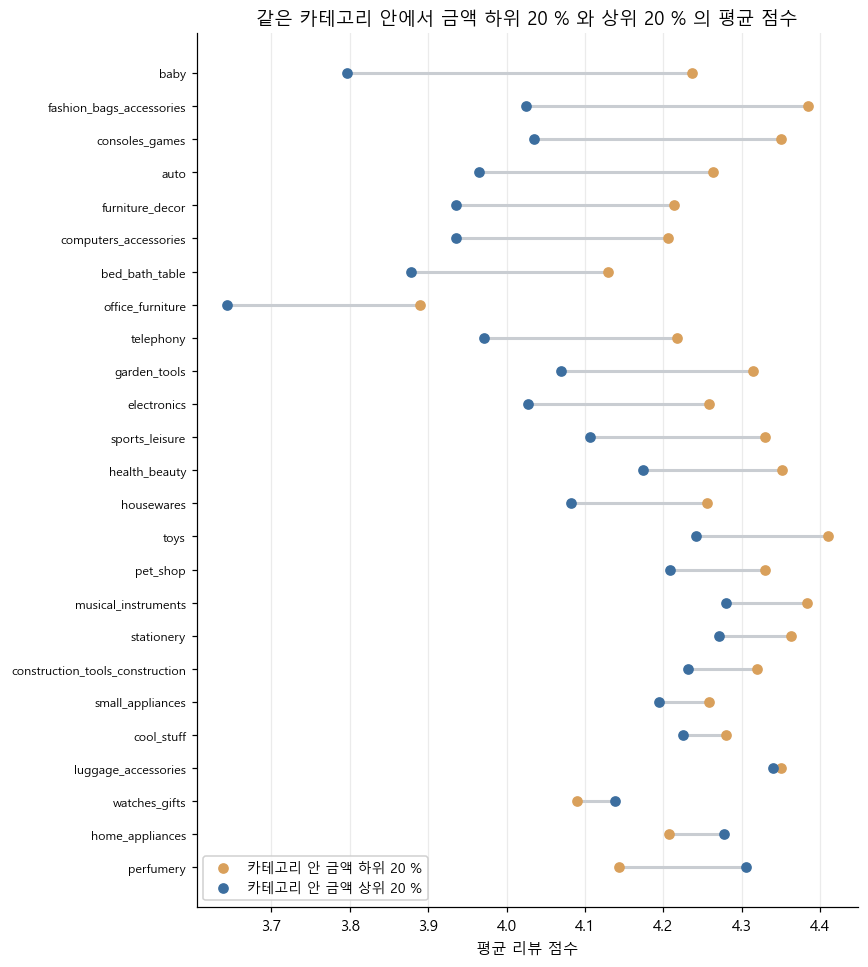

In [26]:
c = cat.sort_values('gap', ascending=False).reset_index(drop=True)
y = list(range(len(c)))

fig, ax = plt.subplots(figsize=(8, 0.3 * len(c) + 1.4))
ax.hlines(y, c['lo_avg'], c['hi_avg'], color='#C9CDD2', lw=2)
ax.scatter(c['lo_avg'], y, color=SAND, s=36, zorder=3, label='카테고리 안 금액 하위 20 %')
ax.scatter(c['hi_avg'], y, color=BLUE, s=36, zorder=3, label='카테고리 안 금액 상위 20 %')
ax.set_yticks(y)
ax.set_yticklabels(c['category'], fontsize=8)
ax.set_xlabel('평균 리뷰 점수')
ax.set_title('같은 카테고리 안에서 금액 하위 20 % 와 상위 20 % 의 평균 점수')
ax.legend(loc='lower left', framealpha=0.9, fontsize=9)
ax.grid(axis='y', alpha=0)
plt.tight_layout()
plt.show()

25 개 카테고리 중 22 개에서 금액 상위 20 % 의 평균이 하위 20 % 보다 낮다.
차이의 구간이 0 을 포함하지 않는 `낮음` 이 14 개로 주문 65,669 건(76.08 %), 구간이 걸친 카테고리가 10 개 · 17,622 건,
상위 20 % 가 더 높은 `높음` 은 perfumery 1 개(+0.163) · 3,023 건이다. 구간이 걸친 10 개 중 8 개도 차이의 부호는 음수다.

차이가 가장 큰 곳은 baby −0.439, fashion_bags_accessories −0.360, consoles_games −0.315.

## 7. 금액대를 맞춰 평가하면 달라지는가

4 ~ 6 에서 금액 분위마다 점수의 기준선이 다르고 그 차이가 배송이나 카테고리로 다 설명되지 않는 것을 보았다.
기준선이 다르면 점수를 그대로 견주는 평가에서 고액 주문을 많이 받은 쪽이 불리하다.

기준선은 분위마다 약속을 지킨 주문의 평균으로 잡는다. 분위의 전체 평균을 쓰면 5 에서 약속 위반이 설명한 몫까지 기준선에 들어가,
고액 주문에서 약속을 어긴 쪽도 그만큼 점수를 돌려받는다.
분위 `d` 의 보정값은 `약속을 지킨 주문 전체의 평균 − 분위 d 에서 약속을 지킨 주문의 평균` 이고,
주문의 점수에 그 주문이 속한 분위의 보정값을 더한다. 약속 위반으로 낮아진 점수는 되돌리지 않는다.
약속을 지킨 주문도 금액이 높은 분위일수록 소요일이 길어, 5 에서 본 소요일 구성의 몫은 기준선에 남는다.

- `orders` · `avg_score` — 분위의 주문 수와 평균 점수
- `kept_orders` · `kept_avg` — 그중 약속을 지킨 주문의 수와 평균 점수
- `adjustment` — 그 분위 주문에 더할 보정값

In [27]:
con.execute("""
WITH k AS (
    SELECT AVG(review_score) AS km
    FROM amount_review
    WHERE days_vs_promise <= 0
)
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')                          AS decile,
       COUNT(*)                                                             AS orders,
       ROUND(AVG(review_score), 3)                                          AS avg_score,
       COUNT(*) FILTER (days_vs_promise <= 0)                               AS kept_orders,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)            AS kept_avg,
       ROUND(MIN(k.km) - AVG(review_score) FILTER (days_vs_promise <= 0), 3) AS adjustment
FROM amount_review
CROSS JOIN k
GROUP BY amount_decile
ORDER BY decile
""").df()

,decile,orders,avg_score,kept_orders,kept_avg,adjustment
0,01,9556,4.246,9044,4.347,-0.056
1,02,9556,4.243,8997,4.362,-0.071
2,03,9556,4.207,8978,4.329,-0.038
3,04,9556,4.194,8925,4.332,-0.041
4,05,9556,4.160,8902,4.295,-0.004
5,06,9556,4.168,8911,4.302,-0.011
6,07,9556,4.152,8888,4.294,-0.003
7,08,9556,4.104,8853,4.257,0.034
8,09,9556,4.064,8884,4.210,0.081
9,10,9556,4.023,8800,4.178,0.113


보정값은 1 분위 −0.056, 10 분위 +0.113 이다. 약속을 지킨 주문의 평균이 1 분위 4.347 에서 10 분위 4.178 로 내려가는 폭 0.169 가
양 끝의 차이가 된다. 가장 큰 음수는 2 분위 −0.071 로, 약속을 지킨 주문의 평균이 4.362 로 가장 높은 분위다.

보정이 실제 평가를 바꾸는지 판매자로 확인한다. 07 은 판매자별 평균의 95 % 상한이 전체 평균보다 낮고
1 ~ 2 점 비율의 Wilson 하한이 전체 1 ~ 2 점 비율보다 높은 판매자를 고객 만족도가 지속적으로 낮다고 판정했다.
같은 판정을 보정 전후로 해 걸리는 판매자가 어떻게 달라지는지 본다.

두 구간은 07 과 같이 원래 점수로 구하고 비교 기준만 바꾼다. 보정 전 기준은 표본 전체의 평균과 1 ~ 2 점 비율이다.
보정 뒤 기준은 판매자마다 다르다. `전체 값 + (그 판매자의 금액 분위 구성이 예상하는 값 − 표본 전체가 예상하는 값)` 이고,
예상하는 값은 위와 같이 약속을 지킨 주문의 분위별 평균과 1 ~ 2 점 비율로 만든다.
보정한 비율은 이항 비율이 아니어서 Wilson 하한을 걸 수 없지만, `보정한 비율 > 전체 비율` 은 `실제 비율 > 판매자별 기준` 과 같으므로
Wilson 하한은 실제 비율에 그대로 건다.

07 의 뷰에 기대지 않도록 판매자가 하나인 주문이라는 조건을 여기서 다시 건다.

- `group` — 보정 전후로 판정이 어떻게 갈리는지
- `sellers` · `orders` — 판매자 수와 주문 수
- `high_share` — 그 판매자들의 주문 중 금액 8 ~ 10 분위가 차지하는 비율의 평균
- `late_pct` — 약속 위반율의 판매자 평균
- `raw_avg` · `adj_avg` — 원래 평균과 보정 평균의 판매자 평균. 보정 평균은 판매자별 기준과의 차이를 표본 전체 기준에 옮겨 적은 값
- `raw_low_pct` · `adj_low_pct` — 1 ~ 2 점 비율을 같은 방식으로 적은 값

In [28]:
con.execute("""
WITH one_seller AS (
    SELECT order_id,
           MIN(seller_id) AS seller_id
    FROM order_items
    GROUP BY order_id
    HAVING COUNT(DISTINCT seller_id) = 1
),
s AS (
    SELECT os.seller_id,
           a.amount_decile AS d,
           a.review_score,
           a.days_vs_promise
    FROM amount_review AS a
    JOIN one_seller    AS os ON os.order_id = a.order_id
),
dec AS (
    SELECT amount_decile                                                                        AS d,
           AVG(review_score)                                      FILTER (days_vs_promise <= 0) AS kd,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) FILTER (days_vs_promise <= 0) AS kl
    FROM amount_review
    GROUP BY amount_decile
),
scored AS (
    SELECT s.*,
           dec.kd,
           dec.kl
    FROM s
    JOIN dec USING (d)
),
o AS (
    SELECT AVG(review_score)                                      AS m,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS l,
           AVG(kd)                                                AS ekd,
           AVG(kl)                                                AS ekl
    FROM scored
),
per AS (
    SELECT seller_id,
           COUNT(*)                                                        AS n,
           AVG(review_score)                                               AS avg_score,
           STDDEV_SAMP(review_score)                                       AS sd,
           SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END)              AS low_n,
           AVG(kd)                                                         AS skd,
           AVG(kl)                                                         AS skl,
           100.0 * AVG(CASE WHEN d >= 8 THEN 1.0 ELSE 0.0 END)             AS high_share,
           100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS late_pct
    FROM scored
    GROUP BY seller_id
),
calc AS (
    SELECT per.*,
           o.m,
           o.l,
           per.avg_score + 1.96 * per.sd / SQRT(per.n)                     AS ci_high,
           1.0 * per.low_n / per.n                                         AS low_rate,
           ((1.0 * per.low_n / per.n + 1.9208 / per.n)
            - 1.96 * SQRT((1.0 * per.low_n / per.n)
                          * (1 - 1.0 * per.low_n / per.n) / per.n
                          + 0.9604 / (per.n * per.n)))
           / (1 + 3.8416 / per.n)                                          AS wilson_low,
           o.m + per.skd - o.ekd                                           AS thr_mean,
           o.l + per.skl - o.ekl                                           AS thr_low,
           o.ekd,
           o.ekl
    FROM per
    CROSS JOIN o
),
judge AS (
    SELECT calc.*,
           COALESCE(ci_high < m        AND wilson_low > l,       FALSE) AS flag_raw,
           COALESCE(ci_high < thr_mean AND wilson_low > thr_low, FALSE) AS flag_adj
    FROM calc
)
SELECT CASE WHEN flag_raw AND NOT flag_adj THEN '1. 보정 뒤 빠짐'
            WHEN flag_raw AND flag_adj     THEN '2. 둘 다 걸림'
            WHEN NOT flag_raw AND flag_adj THEN '3. 보정 뒤 새로 걸림'
            ELSE                                '4. 둘 다 안 걸림' END AS "group",
       COUNT(*)                                        AS sellers,
       CAST(SUM(n) AS BIGINT)                          AS orders,
       ROUND(AVG(high_share), 1)                       AS high_share,
       ROUND(AVG(late_pct), 1)                         AS late_pct,
       ROUND(AVG(avg_score), 3)                        AS raw_avg,
       ROUND(AVG(avg_score - skd + ekd), 3)            AS adj_avg,
       ROUND(100 * AVG(low_rate), 1)                   AS raw_low_pct,
       ROUND(100 * AVG(low_rate - skl + ekl), 1)       AS adj_low_pct
FROM judge
GROUP BY "group"
ORDER BY "group"
""").df()

,group,sellers,orders,high_share,late_pct,raw_avg,adj_avg,raw_low_pct,adj_low_pct
0,1. 보정 뒤 빠짐,8,551,75.4,13.0,3.411,3.474,34.1,32.2
1,2. 둘 다 걸림,86,13149,34.3,19.1,3.036,3.044,41.6,41.4
2,3. 보정 뒤 새로 걸림,8,2794,4.5,8.4,3.851,3.809,20.2,21.5
3,4. 둘 다 안 걸림,2820,77808,36.5,6.7,4.261,4.271,10.7,10.4


**보정 전 판정은 07 과 같다.** 걸리는 판매자가 94 곳 · 주문 13,700 건이다.

**보정하면 94 곳 중 8 곳이 빠지고 다른 8 곳이 새로 걸린다.** 걸리는 수는 그대로지만 같은 집합이 아니다.
빠지는 8 곳은 주문의 75.4 % 가 금액 8 ~ 10 분위이고, 새로 걸리는 8 곳은 4.5 % 뿐이다.

빠지는 8 곳의 약속 위반율은 13.0 % 로 둘 다 걸리지 않는 판매자들의 6.7 % 보다 높다.
기준선에서 약속 위반의 몫을 뺐으므로 위반으로 낮아진 점수는 판정에 그대로 남아 있고, 판정이 바뀐 것은 금액 분위 때문이다.

둘 다 걸리는 86 곳은 금액 8 ~ 10 분위 비중이 34.3 % 로 둘 다 걸리지 않는 판매자들의 36.5 % 와 비슷하고,
평균도 3.036 에서 3.044 로 거의 움직이지 않는다. 금액 구성이 한쪽으로 치우친 판매자에게서만 판정이 갈린다.

## 8. 정리

### 가설의 판정

**조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮다.** 성립한다.

금액 10 분위의 평균 점수가 1 분위 4.246 에서 10 분위 4.023 으로 대체로 한 방향으로 내려가고,
차이 −0.223 의 95 % 구간 −0.260 ~ −0.186 이 0 을 포함하지 않는다. 10 개 분위를 모두 쓴 기울기는
분위당 −0.0236(−0.0264 ~ −0.0208) 이다. 1 ~ 2 점 비율은 10.27 % 에서 16.87 % 로 오른다.

**조건 2 — 약속 준수 여부와 소요일의 영향을 제외해도 방향이 남는다.** 성립한다.

전체 기울기 −0.0236 중 배송이 설명하는 몫은 −0.0108(45.6 %) 이고 남는 몫이 −0.0128(54.4 %) 다.
배송 몫은 약속 위반 구성 −0.0051(21.8 %) 과 소요일 구성 −0.0056(23.8 %) 으로 갈린다.

금액이 높은 분위일수록 약속 위반율이 높고(5.36 % → 7.91 %) 소요일 중앙값도 길다(8 일 → 11 일).
소요일의 영향을 제외해도 0 ~ 7 일 −0.0116, 8 ~ 14 일 −0.0120, 15 ~ 21 일 −0.0142, 22 ~ 30 일 −0.0211 로
네 구간 모두 95 % 구간이 0 을 포함하지 않는다.

운임으로 나눈 10 분위에서는 격차가 더 크다. 평균 점수가 4.344 에서 3.874 로 −0.470 이고
소요일 중앙값이 5 일에서 13 일로 벌어진다.

**조건 3 — 같은 카테고리 안에서도 방향이 남는다.** 성립한다.

주문 500 건 이상인 카테고리의 같은 주문에서 전체 금액 분위의 기울기가 −0.0203, 카테고리 안에서 다시 나눈 분위의 기울기가
−0.0218 로 카테고리 가격대를 걷어내도 기울기가 줄지 않는다. 카테고리 구성이 설명하는 몫은 보이지 않는다.

카테고리 사이에서는 금액 중앙값과 평균 점수의 상관계수가 −0.315 이나 95 % 구간이 −0.631 ~ 0.092 로 0 을 포함한다.
카테고리 안의 평균 점수는 4.259 에서 4.032 로 −0.227 이고, 카테고리별로는 25 개 중 22 개에서
상위 20 % 가 하위 20 % 보다 낮으며 그중 14 개(주문 65,669 건)는 차이의 구간이 0 을 포함하지 않는다.

### 제안

**주문의 질을 점수로 평가할 때 금액대를 맞춰 비교해야 한다.**
약속을 지킨 주문만 보아도 금액 분위마다 점수의 기준선이 4.347 에서 4.178 까지 다르고, 그 차이는 배송으로도 카테고리 구성으로도 다 설명되지 않는다.
점수를 그대로 견주면 고액 주문을 많이 받은 쪽이 그만큼 낮게 읽힌다.

**보정값은 약속을 지킨 주문의 분위별 평균에서 나온다.** 1 분위 −0.056 에서 10 분위 +0.113 이고,
주문의 점수에 그 주문이 속한 분위의 보정값을 더하면 된다. 약속 위반으로 낮아진 점수는 되돌리지 않는다.
내보내는 파일에 이 값을 함께 담았다.

**보정은 07 의 판정을 바꾼다.** 07 의 두 기준에 판매자별 기준을 적용하면 걸리던 94 곳 중 8 곳이 빠지고 다른 8 곳이 새로 걸린다.
빠지는 쪽은 주문의 75.4 % 가 금액 8 ~ 10 분위이고 새로 걸리는 쪽은 4.5 % 다.
금액 구성이 한쪽으로 치우친 판매자에게서만 판정이 갈리므로, 판매자를 점수로 판정하는 자리에서는 이 보정을 거치는 편이 낫다.

**배송 쪽 개입만으로는 절반도 줄지 않는다.**
전체 기울기 중 배송이 설명하는 몫은 45.6 % 이고, 그중 예상 도착일로 다룰 수 있는 약속 위반 구성은 21.8 % 다.

### 이 분석이 답하지 못하는 것

**운임과 주문 금액 중 어느 쪽이 얼마나 움직이는가.** 확인하지 않음.
둘의 상관이 0.491 이고 운임 분위를 따라 주문 금액도 함께 오른다.

**금액 상위 주문에서 무엇이 낮은 평가를 만드는가.** 확인하지 않음.
상품 정보량(사진 수 · 설명 길이)과 무게는 이 노트북에서 다루지 않았다.

## 9. 내보내기

Tableau 는 DuckDB 에 직접 붙지 못하므로 주문 단위 한 장을 파일로 뽑는다.
주문 금액과 그 구성, 금액 10 분위, 카테고리와 카테고리 안의 금액 10 분위(주문 500 건 이상 카테고리만),
약속 대비 값과 리뷰 점수, 7 의 금액 보정값을 담아 4 ~ 7 의 표와 그림을 파일 하나에서 다시 만들 수 있게 한다.

- `amount_adjustment` — 그 주문이 속한 금액 분위의 보정값
- `adjusted_score` — 리뷰 점수에 보정값을 더한 값

내보낸 파일을 다시 읽어 행 수와 금액 분위별 주문 수 · 평균 점수 · 1 ~ 2 점 비율을 4 의 출력과 대조하고,
보정값과 보정한 평균도 함께 본다. 약속을 지킨 주문의 보정한 평균(`avg_adjusted_kept`)은 정의상 분위마다 같아야 하고,
전체 주문의 보정한 평균(`avg_adjusted`)에는 되돌리지 않은 약속 위반의 몫이 분위마다 다르게 남는다.

In [29]:
import os

os.makedirs('../exports', exist_ok=True)

con.execute("""
COPY (
    WITH big AS (
        SELECT category
        FROM amount_review
        WHERE category IS NOT NULL
        GROUP BY category
        HAVING COUNT(*) >= 500
    ),
    q AS (
        SELECT a.order_id,
               NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS category_decile
        FROM amount_review AS a
        JOIN big USING (category)
    ),
    o AS (
        SELECT AVG(review_score) AS m
        FROM amount_review
        WHERE days_vs_promise <= 0
    ),
    adj AS (
        SELECT amount_decile                                              AS d,
               MIN(o.m) - AVG(review_score) FILTER (days_vs_promise <= 0) AS amount_adjustment
        FROM amount_review
        CROSS JOIN o
        GROUP BY amount_decile
    )
    SELECT a.order_id,
           a.customer_state,
           CAST(a.order_purchase_timestamp AS DATE) AS purchase_date,
           a.items,
           a.products,
           ROUND(a.price_sum, 2)                    AS price_sum,
           ROUND(a.freight_sum, 2)                  AS freight_sum,
           ROUND(a.order_amount, 2)                 AS order_amount,
           a.amount_decile,
           a.category,
           q.category_decile,
           a.delivery_days,
           a.days_vs_promise,
           a.days_vs_promise <= 0                   AS kept,
           a.review_score,
           ROUND(adj.amount_adjustment, 3)          AS amount_adjustment,
           ROUND(a.review_score + adj.amount_adjustment, 3) AS adjusted_score
    FROM amount_review AS a
    LEFT JOIN q   ON q.order_id = a.order_id
    JOIN      adj ON adj.d      = a.amount_decile
    ORDER BY a.order_amount, a.order_id
) TO '../exports/08_amount_review.csv' (HEADER, DELIMITER ',')
""")

rows = con.execute(
    "SELECT COUNT(*) FROM read_csv_auto('../exports/08_amount_review.csv')").fetchone()[0]
print(f'../exports/08_amount_review.csv — {rows:,} 행')

con.execute("""
WITH f AS (SELECT * FROM read_csv_auto('../exports/08_amount_review.csv'))
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')                               AS decile,
       COUNT(*)                                                                 AS orders,
       ROUND(AVG(review_score), 3)                                              AS avg_score,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS low_pct,
       ROUND(MIN(amount_adjustment), 3)                                         AS amount_adjustment,
       ROUND(AVG(adjusted_score), 3)                                            AS avg_adjusted,
       ROUND(AVG(adjusted_score) FILTER (kept), 3)                              AS avg_adjusted_kept
FROM f
GROUP BY amount_decile
ORDER BY decile
""").df()

../exports/08_amount_review.csv — 95,560 행


,decile,orders,avg_score,low_pct,amount_adjustment,avg_adjusted,avg_adjusted_kept
0,01,9556,4.246,10.27,-0.056,4.190,4.291
1,02,9556,4.243,10.27,-0.071,4.172,4.291
2,03,9556,4.207,11.49,-0.038,4.169,4.291
3,04,9556,4.194,11.55,-0.041,4.153,4.291
4,05,9556,4.160,12.58,-0.004,4.156,4.291
5,06,9556,4.168,12.45,-0.011,4.157,4.291
6,07,9556,4.152,12.76,-0.003,4.149,4.291
7,08,9556,4.104,14.33,0.034,4.138,4.291
8,09,9556,4.064,15.40,0.081,4.145,4.291
9,10,9556,4.023,16.87,0.113,4.136,4.291


## 10. 연결 종료

DuckDB 파일은 한 프로세스만 쓰기 모드로 열 수 있으므로 다음 노트북을 위해 여기서 종료.
뷰 `amount_review` 는 DB 파일에 저장되어 연결을 닫아도 유지.

In [30]:
con.close()